In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path
from sklearn.preprocessing import OrdinalEncoder , StandardScaler , LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline ,Pipeline 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from pandas.plotting import scatter_matrix
sys.path.append("../src")
sys.path.append("../data/")
from utils import *

In [2]:
data = pd.read_csv("../data/AdultCensusIncomeDataset/adult.csv")
RS = 42
DLFXD = ['income']

In [3]:
X = data.drop(DLFXD , axis=1) ; y = data['income'].copy().to_frame()
X_categorial_Types = X.select_dtypes(include=['object']).columns ; X_numerical_types = X.select_dtypes(include=['int64' , 'float64']).columns

In [4]:
numerical_pipeline  = Pipeline([
    ('imputer' , SimpleImputer(strategy='most_frequent')),
    ('scaler' , StandardScaler())
])

categorial_pipeline = Pipeline([
    ('imputer' , SimpleImputer(strategy='most_frequent')),
    ('cat_to_num' , OrdinalEncoder(handle_unknown='error'))
])
Y_pipeline          = Pipeline([
    ('imputer' , SimpleImputer(strategy='most_frequent')),
    ('cat' ,  OrdinalEncoder(handle_unknown='error'))
])

In [5]:
preprocessing_pipeline_Xv = ColumnTransformer([
    ('cat' , categorial_pipeline , X_categorial_Types),
    ('num', numerical_pipeline , X_numerical_types)
])
preprocessing_pipeline_Yv = ColumnTransformer([
    ('num', Y_pipeline , ['income'])
])

In [6]:
y = preprocessing_pipeline_Yv.fit_transform(y);X = preprocessing_pipeline_Xv.fit_transform(X)
X_train , X_valid , y_train , y_valid = train_test_split(X , y[: , 0] , test_size=0.2 , stratify=data['income'] , random_state=RS)

In [7]:
lr_model = LogisticRegression(random_state=RS)
lr_model.fit(X_train , y_train)

c:\Users\kuoro\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [8]:
y_pred = lr_model.predict(X_valid)

In [9]:
print_classification_metrics(y_valid , y_pred)

Accuracy:  0.8285
Precision: 0.7235
Recall:    0.4656
F1-Score:  0.5666


c:\Users\kuoro\Documents\GitHub\MLProjects\notebooks\../src\utils.py:79: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper left")


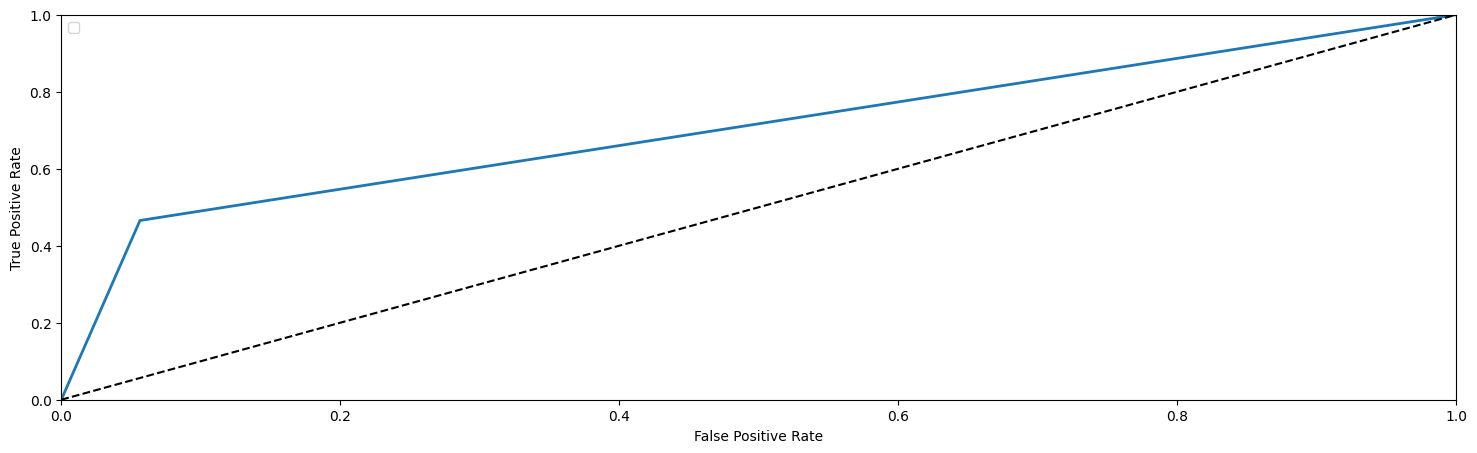

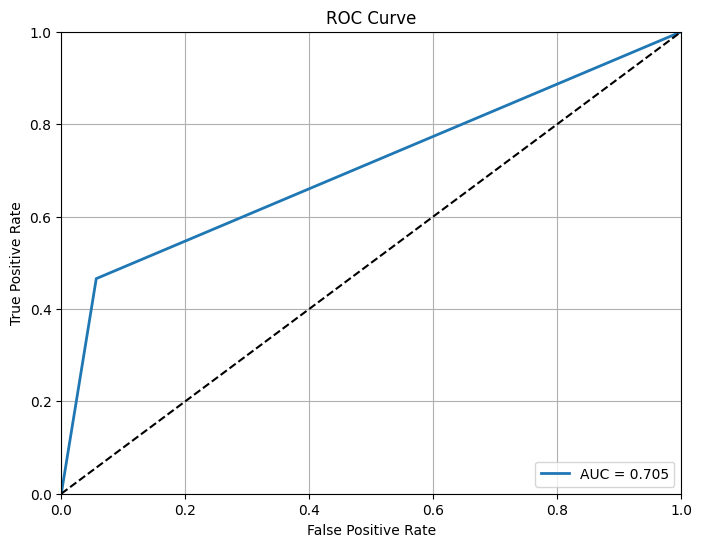

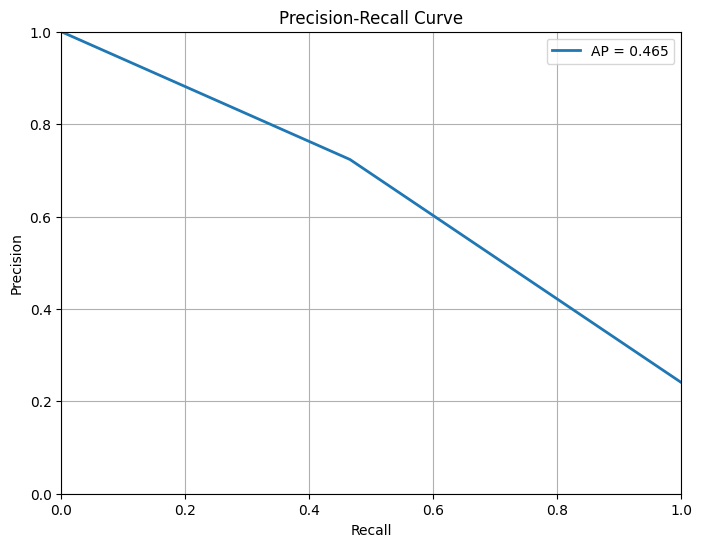

0.46549398515228285

In [10]:
plot_roc_curve(y_valid , y_pred , save=Path(f"../tests/Project_1_plots/roc_curve_plot_pipelinev1_linearregression_seed_{RS}.png"))
plot_roc_curve_with_auc(y_valid , y_pred , save=Path(f"../tests/Project_1_plots/roc_curve_with_auc_plot_pipelinev1_linearregression_seed_{RS}.png"))
plot_pr_curve_with_ap(y_valid , y_pred , save=Path(f"../tests/Project_1_plots/pr_curve_with_ap_plot_pipelinev1_linearregression_seed_{RS}.png"))

# Runs

#### run with linear model and standard scaler and nothing else
- -> Accuracy:  0.8285
- -> Precision: 0.7235
- -> Recall:    0.4656
- -> F1-Score:  0.5666
